# Análise Exploratória dos Fatores Associados ao Cancelamento de Clientes em Operadoras de Telecomunicações

**Especialização em Ciência de Dados - UTFPR**

Autor: Janyne Soares

Base de dados: Telco Customer Churn

In [410]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [411]:
#Configuração do Seaborn e Matplotlib
import seaborn as sns

sns.set_theme(
    style="white",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [412]:
#Leitura da base
# Carregando a base
df = pd.read_csv("../dados/brutos/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Inspeção inicial
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 4. Pré-processamento dos Dados

In [413]:
# Criando uma cópia da base original
df_tratado = df.copy()

In [414]:
# Renomeando as colunas para facilitar a leitura e interpretação da análise
df_tratado = df_tratado.rename(columns={
    "customerID": "id_cliente",
    "gender": "genero",
    "SeniorCitizen": "idoso",
    "Partner": "parceiro",
    "Dependents": "dependentes",
    "tenure": "tempo_permanencia",
    "PhoneService": "servico_telefone",
    "MultipleLines": "multiplas_linhas",
    "InternetService": "servico_internet",
    "OnlineSecurity": "seguranca_online",
    "OnlineBackup": "backup_online",
    "DeviceProtection": "protecao_dispositivo",
    "TechSupport": "suporte_tecnico",
    "StreamingTV": "streaming_tv",
    "StreamingMovies": "streaming_filmes",
    "Contract": "tipo_contrato",
    "PaperlessBilling": "fatura_digital",
    "PaymentMethod": "metodo_pagamento",
    "MonthlyCharges": "cobranca_mensal",
    "TotalCharges": "cobranca_total",
    "Churn": "cancelamento"
})

df_tratado.head()

,id_cliente,genero,idoso,parceiro,dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cancelamento
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [415]:
# Convertendo a coluna cobranca_total para numérico
df_tratado["cobranca_total"] = df_tratado["cobranca_total"].replace(" ", np.nan)

df_tratado["cobranca_total"] = pd.to_numeric(
    df_tratado["cobranca_total"],
    errors="coerce"
)

df_tratado["cobranca_total"].dtype

dtype('float64')

In [416]:
# Removendo registros sem valor de cobrança total
df_tratado = df_tratado.dropna(subset=["cobranca_total"])

# Conferindo
df_tratado["cobranca_total"].isnull().sum()

np.int64(0)

In [417]:
df_tratado["cobranca_total"].isnull().sum()

np.int64(0)

In [418]:
df_tratado.shape

(7032, 21)

In [419]:
df_tratado.columns

Index(['id_cliente', 'genero', 'idoso', 'parceiro', 'dependentes',
       'tempo_permanencia', 'servico_telefone', 'multiplas_linhas',
       'servico_internet', 'seguranca_online', 'backup_online',
       'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
       'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'cobranca_mensal', 'cobranca_total',
       'cancelamento'],
      dtype='str')

In [420]:
# Dicionário com as traduções dos valores categóricos

traducao = {
    "Male": "Masculino",
    "Female": "Feminino",

    "Yes": "Sim",
    "No": "Não",

    "Month-to-month": "Mensal",
    "One year": "1 ano",
    "Two year": "2 anos",

    "Fiber optic": "Fibra óptica",
    "No internet service": "Sem serviço de internet",
    "No phone service": "Sem serviço telefônico",

    "Electronic check": "Cheque eletrônico",
    "Mailed check": "Cheque por correspondência",
    "Bank transfer (automatic)": "Transferência bancária automática",
    "Credit card (automatic)": "Cartão de crédito automático"
}

In [421]:
# Aplicando as traduções em todas as colunas da base
df_tratado = df_tratado.replace(traducao)

df_tratado.head()

,id_cliente,genero,idoso,parceiro,dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cancelamento
0,7590-VHVEG,Feminino,0,Sim,Não,1,Não,Sem serviço telefônico,DSL,Não,...,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico,29.85,29.85,Não
1,5575-GNVDE,Masculino,0,Não,Não,34,Sim,Não,DSL,Sim,...,Sim,Não,Não,Não,1 ano,Não,Cheque por correspondência,56.95,1889.50,Não
2,3668-QPYBK,Masculino,0,Não,Não,2,Sim,Não,DSL,Sim,...,Não,Não,Não,Não,Mensal,Sim,Cheque por correspondência,53.85,108.15,Sim
3,7795-CFOCW,Masculino,0,Não,Não,45,Não,Sem serviço telefônico,DSL,Sim,...,Sim,Sim,Não,Não,1 ano,Não,Transferência bancária automática,42.30,1840.75,Não
4,9237-HQITU,Feminino,0,Não,Não,2,Sim,Não,Fibra óptica,Não,...,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico,70.70,151.65,Sim


In [422]:
# Traduzindo a variável "idoso"

df_tratado["idoso"] = df_tratado["idoso"].replace({
    0: "Não",
    1: "Sim"
})

df_tratado["idoso"].value_counts()

idoso
Não    5890
Sim    1142
Name: count, dtype: int64

In [423]:
# Removendo coluna de identificação, pois não será utilizada na análise
df_tratado = df_tratado.drop(columns=["id_cliente"])

df_tratado.head()

,genero,idoso,parceiro,dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cancelamento
0,Feminino,Não,Sim,Não,1,Não,Sem serviço telefônico,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico,29.85,29.85,Não
1,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,Não,Sim,Não,Não,Não,1 ano,Não,Cheque por correspondência,56.95,1889.50,Não
2,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque por correspondência,53.85,108.15,Sim
3,Masculino,Não,Não,Não,45,Não,Sem serviço telefônico,DSL,Sim,Não,Sim,Sim,Não,Não,1 ano,Não,Transferência bancária automática,42.30,1840.75,Não
4,Feminino,Não,Não,Não,2,Sim,Não,Fibra óptica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Cheque eletrônico,70.70,151.65,Sim


In [424]:
# Salvando a base tratada
df_tratado.to_csv("../dados/tratados/telco_churn_tratada.csv", index=False)

# 5. Análise Exploratória dos Dados

## 5.1 Visão Geral da Base

A análise exploratória inicia-se com uma visão geral da base de dados, apresentando indicadores gerais sobre os clientes e a distribuição do cancelamento dos serviços. Essa etapa fornece um panorama inicial da variável de interesse (cancelamento), servindo como base para as análises realizadas nas seções seguintes.

### 5.1.1 Indicadores Gerais

In [425]:
# ======================================
# Indicadores Gerais da Base
# ======================================

# Quantidade total de clientes
total_clientes = len(df_tratado)

# Clientes que cancelaram
clientes_cancelaram = (df_tratado["cancelamento"] == "Sim").sum()

# Clientes que permaneceram
clientes_permaneceram = (df_tratado["cancelamento"] == "Não").sum()

# Taxa de cancelamento
taxa_cancelamento = clientes_cancelaram / total_clientes * 100

print("=" * 45)
print("INDICADORES GERAIS")
print("=" * 45)

print(f"👥 Total de clientes: {total_clientes:,}".replace(",", "."))
print(f"✅ Clientes que permaneceram: {clientes_permaneceram:,}".replace(",", "."))
print(f"❌ Clientes que cancelaram: {clientes_cancelaram:,}".replace(",", "."))
print(f"📉 Taxa de cancelamento: {taxa_cancelamento:.2f}%")

INDICADORES GERAIS
👥 Total de clientes: 7.032
✅ Clientes que permaneceram: 5.163
❌ Clientes que cancelaram: 1.869
📉 Taxa de cancelamento: 26.58%


### 5.1.2 Distribuição do Cancelamento dos Clientes

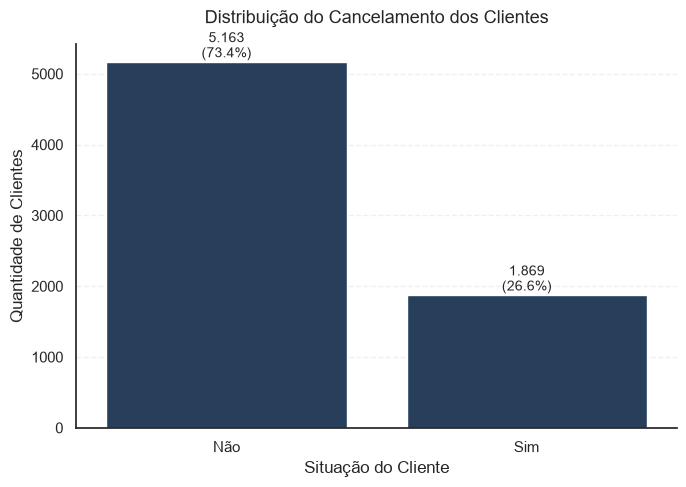

In [426]:
# ======================================
# Distribuição do Cancelamento
# ======================================

cancelamento = (
    df_tratado["cancelamento"]
    .value_counts()
    .reindex(["Não", "Sim"])
)

percentuais = cancelamento / cancelamento.sum() * 100

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=cancelamento.index,
    y=cancelamento.values,
    color="#1E3F63"
)

plt.title("Distribuição do Cancelamento dos Clientes", fontsize=13, pad=15)
plt.xlabel("Situação do Cliente")
plt.ylabel("Quantidade de Clientes")

for i, valor in enumerate(cancelamento.values):
    ax.text(
        i,
        valor + 70,
        f"{valor:,}".replace(",", ".") +
        f"\n({percentuais.iloc[i]:.1f}%)",
        ha="center",
        fontsize=10
    )

ax.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/distribuicao_cancelamento.png", dpi=300)

plt.show()

### 5.1.3 Interpretação

Os indicadores apresentados mostram que a base é composta por **7.043 clientes**, dos quais **1.869 (26,54%)** cancelaram os serviços e **5.174 (73,46%)** permaneceram na operadora. Embora a maioria dos clientes tenha permanecido ativa, observa-se que aproximadamente um quarto da base apresentou cancelamento, indicando que o fenômeno possui relevância suficiente para justificar uma investigação detalhada dos fatores associados ao churn. A distribuição observada servirá como referência para as análises desenvolvidas nas próximas seções.

# Funções Utilizadas na Análise

In [427]:
def grafico_cancelamento_categoria(coluna, titulo, nome_arquivo):

    tabela = (
        pd.crosstab(
            df_tratado[coluna],
            df_tratado["cancelamento"],
            normalize="index"
        ) * 100
    )

    tabela = tabela[["Não", "Sim"]]

    ax = tabela.plot(
        kind="bar",
        figsize=(8, 5),
        color=["#1E3F63", "#A7C7E7"]
    )

    plt.title(titulo, fontsize=13, pad=15)
    plt.xlabel("")
    plt.ylabel("Percentual de Clientes (%)")
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            label_type="edge",
            fontsize=9
        )

    ax.grid(axis="y", linestyle="--", alpha=0.3)

    rotulos = {
        "idoso": ["Não idoso", "Idoso"],
        "parceiro": ["Sem parceiro", "Com parceiro"],
        "dependentes": ["Sem dependentes", "Com dependentes"],
        "fatura_digital": ["Sem fatura digital", "Com fatura digital"],
        "seguranca_online": ["Sem segurança", "Com segurança", "Sem internet"],
        "backup_online": ["Sem backup", "Com backup", "Sem internet"],
        "protecao_dispositivo": ["Sem proteção", "Com proteção", "Sem internet"],
        "suporte_tecnico": ["Sem suporte", "Com suporte", "Sem internet"],
        "streaming_tv": ["Sem Streaming TV", "Com Streaming TV", "Sem internet"],
        "streaming_filmes": ["Sem Streaming", "Com Streaming", "Sem internet"],
        "servico_internet": ["DSL", "Fibra óptica", "Sem internet"],
        "tipo_contrato": ["1 ano", "2 anos", "Mensal"]
    }

    if coluna in rotulos:
        ax.set_xticklabels(rotulos[coluna])

    sns.despine()

    ax.legend(
        title="Situação",
        labels=["Permaneceu", "Cancelou"]
    )

    plt.tight_layout()
    plt.savefig(f"../graficos/{nome_arquivo}.png", dpi=300)
    plt.show()

# 5.2 Perfil dos Clientes

Nesta seção são analisadas características demográficas e familiares dos clientes, buscando identificar se variáveis como gênero, idade, existência de parceiro e dependentes apresentam associação com o cancelamento dos serviços.

## 5.2.1 Gênero

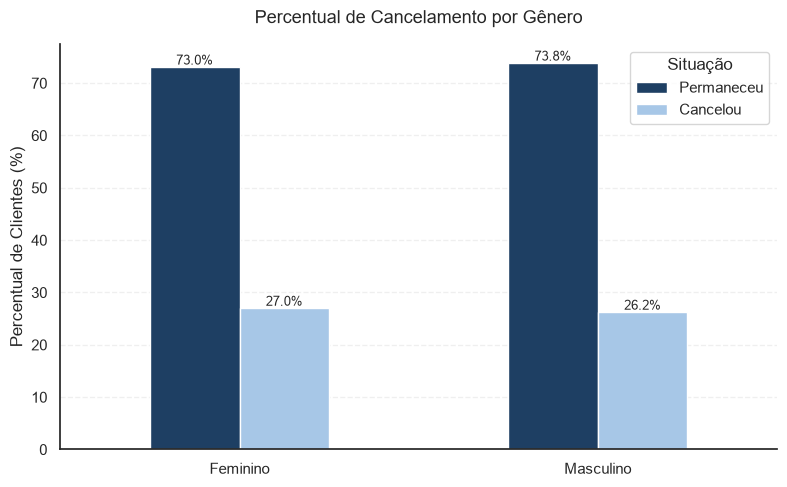

In [428]:
grafico_cancelamento_categoria(
    coluna="genero",
    titulo="Percentual de Cancelamento por Gênero",
    nome_arquivo="cancelamento_por_genero"
)

### Interpretação

Observa-se que a taxa de cancelamento foi bastante semelhante entre clientes do sexo feminino (26,9%) e masculino (26,2%). Essa pequena diferença indica que o gênero, isoladamente, não parece exercer influência significativa sobre a decisão de cancelar os serviços da operadora.

## 5.2.2 Idosos

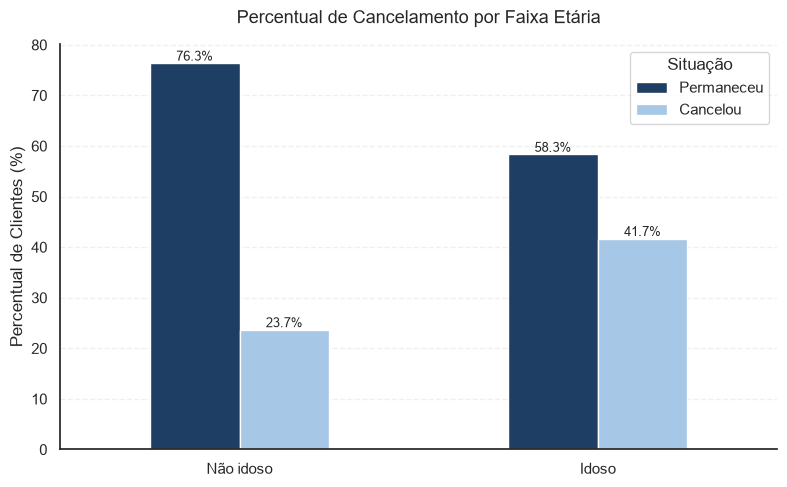

In [429]:
grafico_cancelamento_categoria(
    coluna="idoso",
    titulo="Percentual de Cancelamento por Faixa Etária",
    nome_arquivo="cancelamento_por_idoso"
   
)


### Interpretação

Observa-se uma diferença expressiva entre clientes idosos e não idosos. Enquanto **23,6%** dos clientes não idosos cancelaram os serviços, entre os clientes idosos esse percentual alcança **41,7%**, representando uma diferença de **18,1 pontos percentuais**.

Esse resultado sugere que clientes idosos apresentam maior propensão ao cancelamento dos serviços quando comparados aos demais clientes. Entretanto, por se tratar de uma análise exploratória, não é possível estabelecer uma relação de causa e efeito, sendo necessários estudos complementares para identificar os fatores que contribuem para esse comportamento.

## 5.2.3 Existência de Parceiro

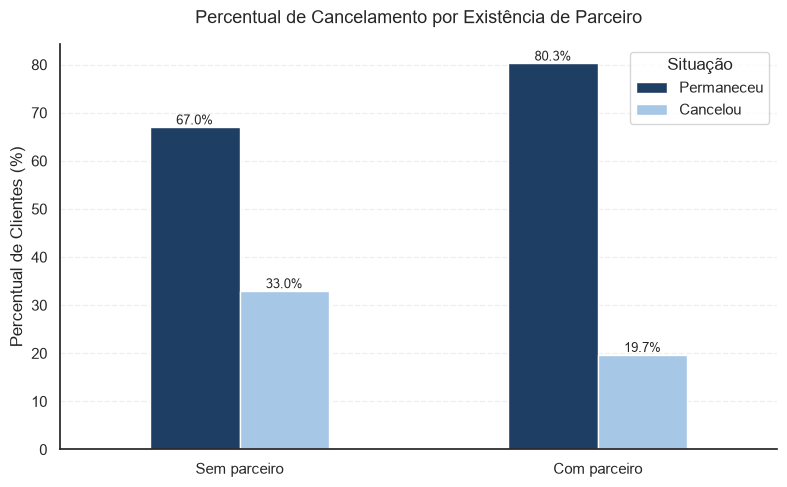

In [430]:
grafico_cancelamento_categoria(
    coluna="parceiro",
    titulo="Percentual de Cancelamento por Existência de Parceiro",
    nome_arquivo="cancelamento_por_parceiro"
)

### Interpretação

Observa-se uma diferença significativa entre clientes com e sem parceiro. Entre os clientes **sem parceiro**, **33,0%** cancelaram os serviços, enquanto entre aqueles **com parceiro** esse percentual foi de **19,7%**, representando uma diferença de **13,3 pontos percentuais**.

Esse resultado sugere que clientes que possuem parceiro tendem a apresentar maior permanência na operadora. 

## 5.2.4 Dependentes

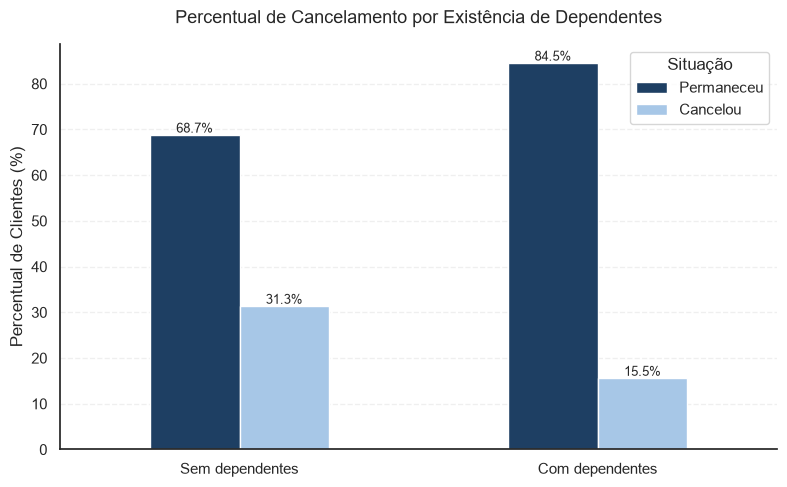

In [431]:
grafico_cancelamento_categoria(
    coluna="dependentes",
    titulo="Percentual de Cancelamento por Existência de Dependentes",
    nome_arquivo="cancelamento_por_dependentes"
)

### Interpretação

A presença de dependentes também apresentou associação com o cancelamento dos serviços. Entre os clientes **sem dependentes**, **31,3%** cancelaram os serviços, enquanto entre aqueles **com dependentes** esse percentual foi de apenas **15,5%**, correspondendo a uma diferença de **15,8 pontos percentuais**.

Esse comportamento indica que clientes com dependentes tendem a permanecer por mais tempo na operadora. Esse resultado pode estar relacionado a perfis de clientes com maior estabilidade ou necessidade de manter os serviços contratados, hipótese que poderá ser explorada em análises futuras.

## 5.2.5 Síntese da Seção

A análise do perfil dos clientes revelou que nem todas as características demográficas apresentam a mesma influência sobre o cancelamento dos serviços. O gênero mostrou percentuais bastante semelhantes entre homens e mulheres, indicando baixa associação com o churn.

Por outro lado, clientes idosos apresentaram uma taxa de cancelamento significativamente superior à dos clientes não idosos. Além disso, observou-se que clientes sem parceiro e sem dependentes cancelaram os serviços com maior frequência quando comparados àqueles que possuem parceiro ou dependentes.

De forma geral, os resultados sugerem que características relacionadas à estrutura familiar e ao perfil do cliente apresentam maior associação com o cancelamento do que o gênero, justificando a continuidade da investigação sobre fatores contratuais, tempo de permanência e serviços contratados nas próximas etapas da análise.

# 5.3 Tempo de Permanência dos Clientes

Nesta seção é analisado o tempo de permanência dos clientes na operadora, buscando verificar se clientes com menor ou maior tempo de relacionamento apresentam comportamentos distintos em relação ao cancelamento dos serviços.

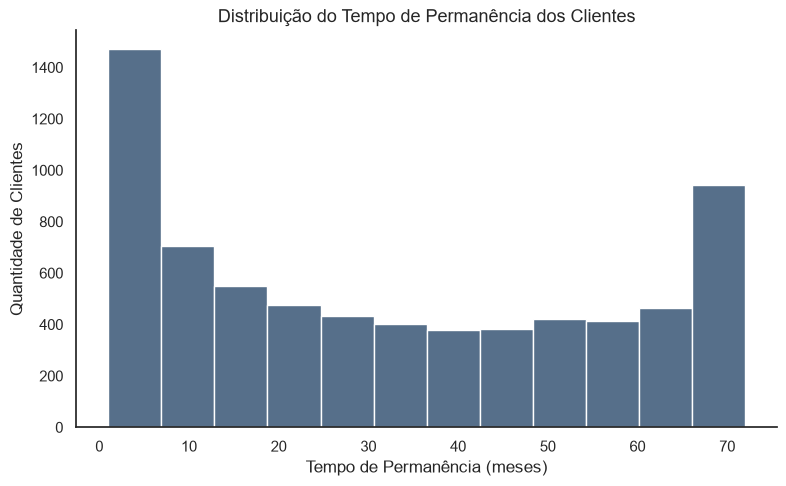

In [432]:

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_tratado,
    x="tempo_permanencia",
    bins=12,
    color="#1E3F63"

)

plt.title("Distribuição do Tempo de Permanência dos Clientes", fontsize=13)
plt.xlabel("Tempo de Permanência (meses)")
plt.ylabel("Quantidade de Clientes")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/distribuicao_tempo_permanencia.png", dpi=300)

plt.show()

###  Interpretação

A distribuição do tempo de permanência evidencia uma concentração de clientes nos primeiros meses de relacionamento com a operadora, bem como um segundo grupo formado por clientes com longo tempo de permanência, próximos ao limite máximo observado na base de dados. Esse comportamento sugere a coexistência de clientes recém-adquiridos e clientes com relacionamento consolidado.

Ao comparar o tempo de permanência entre clientes que permaneceram e aqueles que cancelaram os serviços, observa-se uma diferença expressiva. Os clientes que permaneceram apresentaram tempo médio de permanência de **37,6 meses**, enquanto os clientes que cancelaram permaneceram, em média, **18,0 meses**.

A mediana reforça esse comportamento: entre os clientes que permaneceram, 50% possuem pelo menos **38 meses** de relacionamento com a operadora, enquanto entre os clientes que cancelaram essa mediana é de apenas **10 meses**.

O boxplot evidencia essa diferença ao mostrar que a maior parte dos clientes que cancelaram possui baixo tempo de permanência, embora existam alguns casos isolados de clientes antigos que também realizaram o cancelamento.

De forma geral, os resultados indicam que o tempo de permanência apresenta forte associação com o cancelamento dos serviços, sugerindo que clientes mais recentes tendem a ser mais propensos ao churn do que aqueles que já mantêm um relacionamento consolidado com a operadora.

# 5.3.1 Tempo de Permanência × Cancelamento

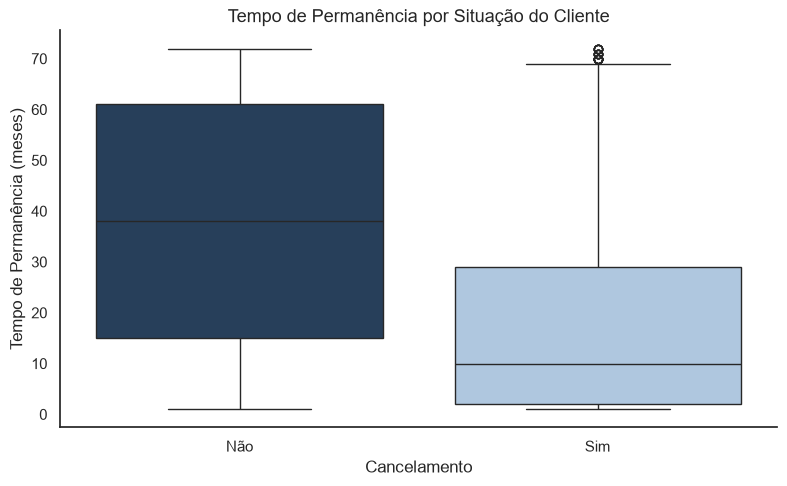

In [433]:
sns.boxplot(
    data=df_tratado,
    x="cancelamento",
    y="tempo_permanencia",
    hue="cancelamento",
    palette=["#1E3F63", "#A7C7E7"],
    legend=False
)
plt.title("Tempo de Permanência por Situação do Cliente", fontsize=13)
plt.xlabel("Cancelamento")
plt.ylabel("Tempo de Permanência (meses)")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/boxplot_tempo_permanencia.png", dpi=300)

plt.show()

In [434]:
df_tratado.groupby("cancelamento")["tempo_permanencia"].describe()

,count,mean,std,min,25%,50%,75%,max
cancelamento,,,,,,,,
Não,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Sim,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Interpretação

Observa-se uma diferença expressiva no tempo de permanência entre clientes que permaneceram na operadora e aqueles que cancelaram os serviços. Os clientes que permaneceram apresentaram tempo médio de permanência de **37,6 meses**, enquanto os clientes que cancelaram permaneceram, em média, **18,0 meses**, ou seja, aproximadamente metade do tempo.

A mediana reforça esse comportamento: entre os clientes que permaneceram, 50% possuem pelo menos **38 meses** de relacionamento com a operadora, enquanto entre os clientes que cancelaram a mediana é de apenas **10 meses**.

O boxplot evidencia essa diferença ao mostrar que a distribuição do tempo de permanência é significativamente menor entre os clientes que cancelaram. Embora existam alguns casos isolados de clientes antigos que também cancelaram os serviços (outliers), observa-se que a maior parte dos cancelamentos ocorre entre clientes com pouco tempo de relacionamento.

Esse resultado sugere que o tempo de permanência apresenta forte associação com o cancelamento, indicando que clientes mais recentes tendem a ser mais propensos ao churn do que aqueles que já possuem um relacionamento consolidado com a operadora.

# 5.4 Tipo de Contrato

Nesta seção é analisada a relação entre o tipo de contrato firmado pelos clientes e o cancelamento dos serviços. O objetivo é verificar se contratos de diferentes durações apresentam comportamentos distintos em relação ao churn.

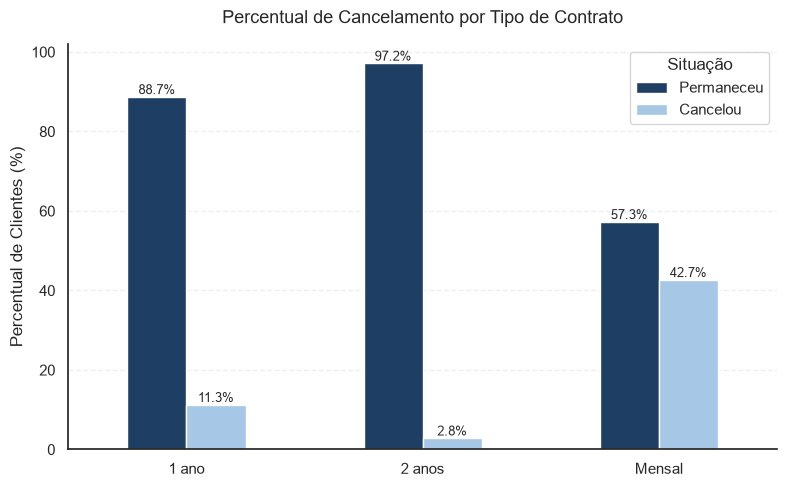

In [435]:
grafico_cancelamento_categoria(
    coluna="tipo_contrato",
    titulo="Percentual de Cancelamento por Tipo de Contrato",
    nome_arquivo="cancelamento_por_tipo_contrato"
)

### Interpretação

A análise do tipo de contrato evidencia uma forte associação entre a duração do vínculo contratual e o cancelamento dos serviços.

Os clientes com **contrato mensal** apresentaram a maior taxa de cancelamento (**42,7%**), valor significativamente superior ao observado entre clientes com contrato de **1 ano** (**11,3%**) e, principalmente, entre aqueles com contrato de **2 anos** (**2,8%**).

Esse comportamento sugere que contratos de maior duração estão associados a uma maior retenção de clientes, enquanto contratos mensais oferecem maior flexibilidade para o encerramento dos serviços, favorecendo taxas mais elevadas de churn.

Entre todas as variáveis analisadas até o momento, o tipo de contrato destaca-se como um dos fatores mais fortemente associados ao cancelamento, indicando que estratégias voltadas ao incentivo de contratos de longo prazo podem contribuir para a redução da evasão de clientes.

# 5.5 Serviços Contratados

Nesta seção são analisados os serviços contratados pelos clientes, buscando verificar se a adesão a determinados serviços está associada ao cancelamento. São considerados os serviços de internet, segurança online, backup online, proteção do dispositivo, suporte técnico, streaming de TV e streaming de filmes.

## 5.5.1 Serviço de Internet

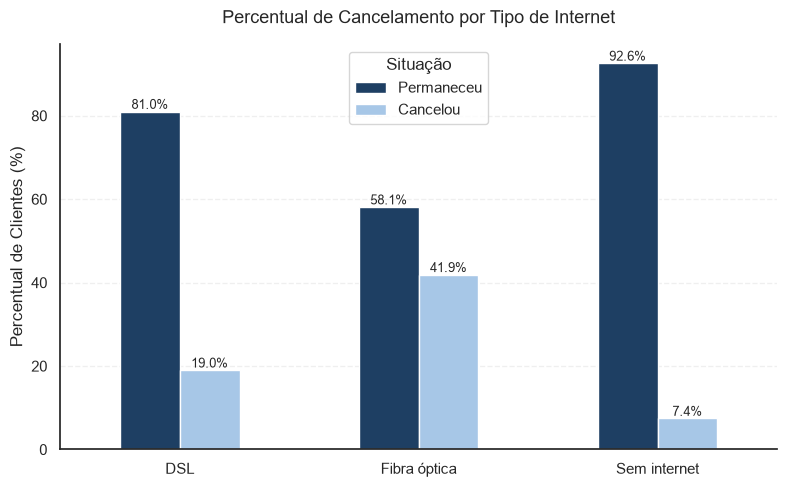

In [436]:
grafico_cancelamento_categoria(
    coluna="servico_internet",
    titulo="Percentual de Cancelamento por Tipo de Internet",
    nome_arquivo="cancelamento_por_internet"
)

## 5.5.2 Segurança Online

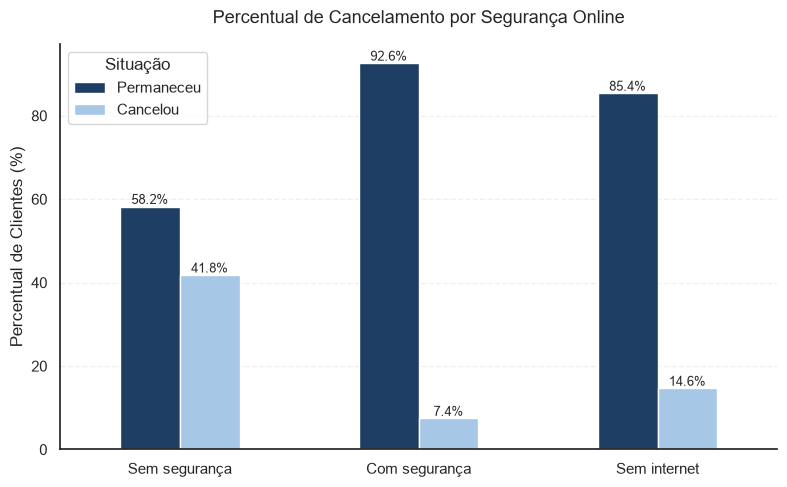

In [437]:
grafico_cancelamento_categoria(
    coluna="seguranca_online",
    titulo="Percentual de Cancelamento por Segurança Online",
    nome_arquivo="cancelamento_por_seguranca"
)

## 5.5.3 Backup Online

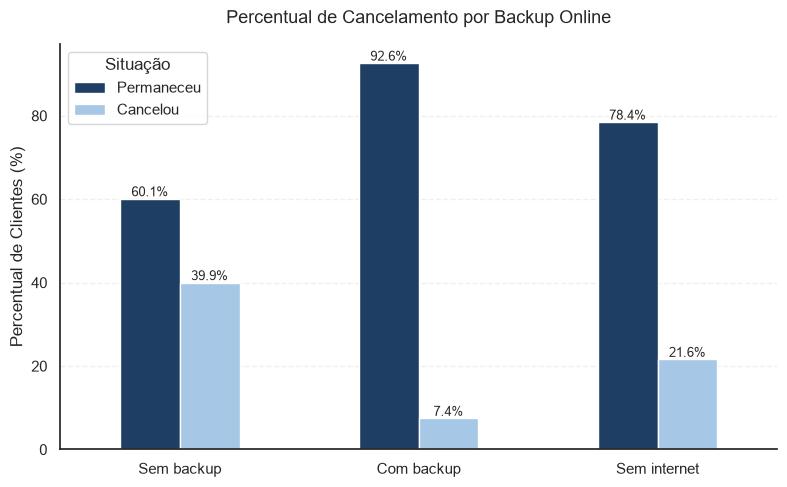

In [438]:
grafico_cancelamento_categoria(
    coluna="backup_online",
    titulo="Percentual de Cancelamento por Backup Online",
    nome_arquivo="cancelamento_por_backup"
)

## 5.5.4 Proteção do Dispositivo

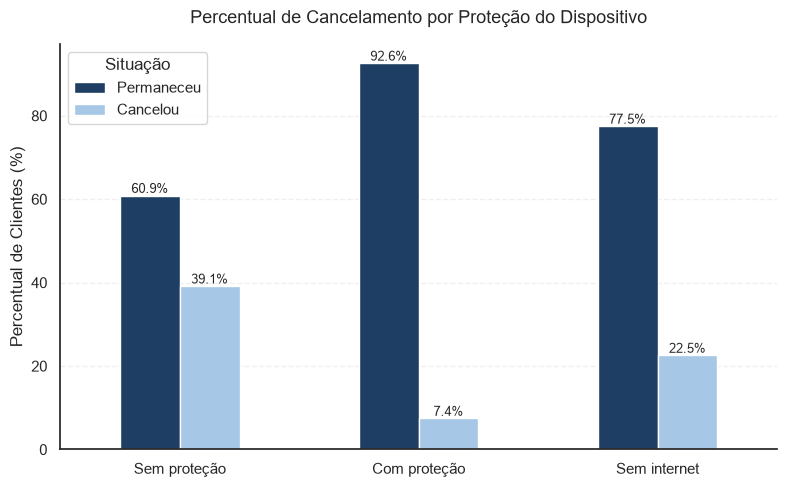

In [439]:
grafico_cancelamento_categoria(
    coluna="protecao_dispositivo",
    titulo="Percentual de Cancelamento por Proteção do Dispositivo",
    nome_arquivo="cancelamento_por_protecao"
)

## 5.5.5 Suporte Técnico

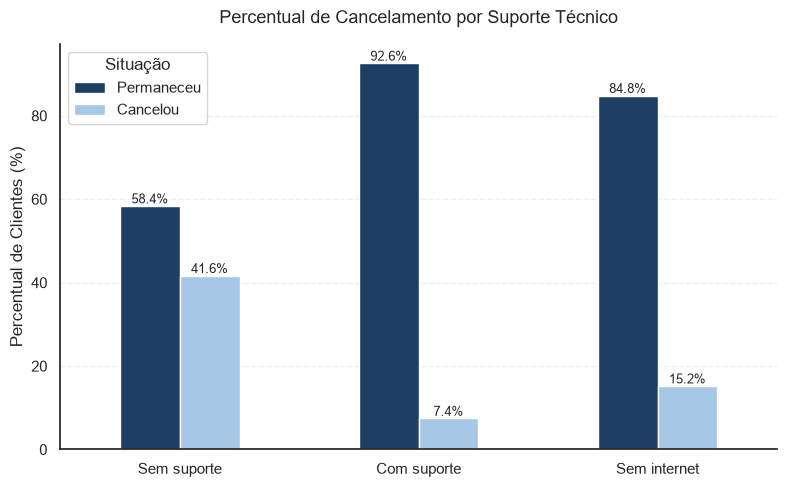

In [440]:
grafico_cancelamento_categoria(
    coluna="suporte_tecnico",
    titulo="Percentual de Cancelamento por Suporte Técnico",
    nome_arquivo="cancelamento_por_suporte"
)

## 5.5.6 Streaming TV

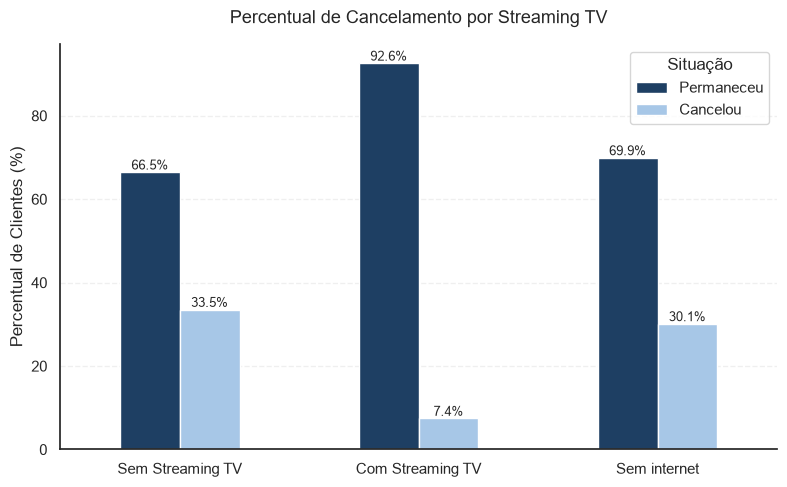

In [441]:
grafico_cancelamento_categoria(
    coluna="streaming_tv",
    titulo="Percentual de Cancelamento por Streaming TV",
    nome_arquivo="cancelamento_por_streaming_tv"
)

## 5.5.7 Streaming Filmes

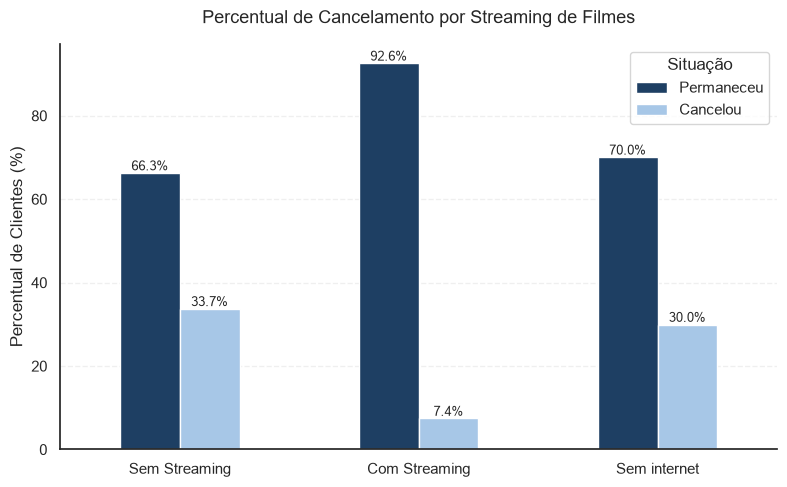

In [442]:
grafico_cancelamento_categoria(
    coluna="streaming_filmes",
    titulo="Percentual de Cancelamento por Streaming de Filmes",
    nome_arquivo="cancelamento_por_streaming_filmes"
)

### Interpretação

A análise dos serviços contratados revelou diferenças importantes nas taxas de cancelamento entre os grupos de clientes.

Em relação ao tipo de internet, os clientes que utilizam **fibra óptica** apresentaram a maior taxa de cancelamento (**41,9%**), enquanto aqueles com conexão **DSL** registraram apenas **19,0%**. Os clientes sem serviço de internet apresentaram baixa taxa de cancelamento (**7,4%**), resultado que deve ser interpretado com cautela, uma vez que esse grupo possui características distintas dos demais.

Também foi observado que clientes que **não possuem serviços adicionais**, como segurança online, backup, proteção do dispositivo e suporte técnico, apresentam taxas de cancelamento significativamente superiores às daqueles que utilizam esses recursos. Por exemplo, clientes sem segurança online apresentaram taxa de cancelamento de **41,8%**, enquanto entre aqueles que utilizam o serviço esse percentual foi de apenas **14,6%**. Comportamento semelhante foi observado para backup online, proteção do dispositivo e suporte técnico.

Os serviços de streaming também apresentaram associação com o cancelamento. Clientes que utilizam streaming de TV ou streaming de filmes registraram taxas de cancelamento próximas de **7,4%**, enquanto aqueles que não utilizam esses serviços apresentaram percentuais próximos de **33%**.

De forma geral, os resultados indicam que clientes que contratam um maior número de serviços adicionais tendem a permanecer por mais tempo na operadora. Entretanto, não é possível afirmar que esses serviços sejam a causa direta da redução do cancelamento, sendo necessários estudos adicionais para avaliar relações de causalidade.

# 5.6 Aspectos Financeiros

Nesta seção são analisadas as características financeiras dos clientes, incluindo valor da cobrança mensal, cobrança total, método de pagamento e utilização de fatura digital. O objetivo é verificar se esses fatores apresentam associação com o cancelamento dos serviços.

# 5.6.1 Distribuição da Cobrança Mensal

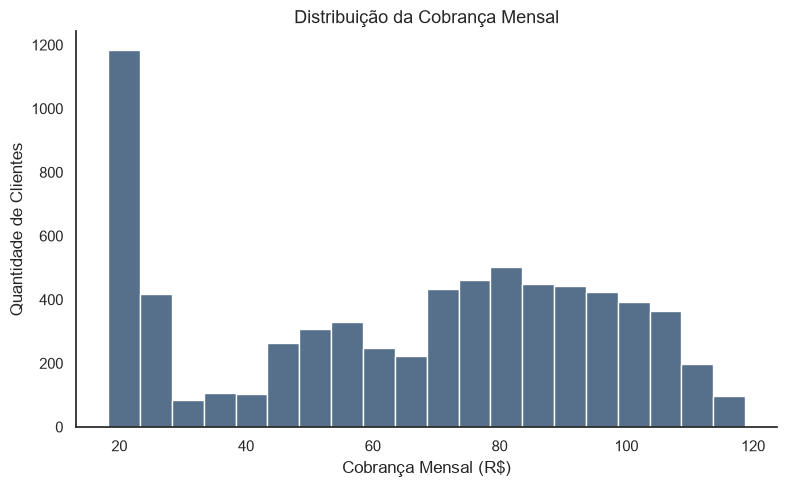

In [443]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_tratado,
    x="cobranca_mensal",
    bins=20,
    color="#1E3F63"
)

plt.title("Distribuição da Cobrança Mensal", fontsize=13)
plt.xlabel("Cobrança Mensal (R$)")
plt.ylabel("Quantidade de Clientes")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/distribuicao_cobranca_mensal.png", dpi=300)

plt.show()

#### Interpretação

A distribuição da cobrança mensal apresenta dois grupos predominantes de clientes. O primeiro concentra-se em valores mais baixos, próximos de R$ 20, enquanto o segundo grupo apresenta cobranças entre aproximadamente R$ 70 e R$ 100. Esse comportamento indica a existência de diferentes perfis de contratação de serviços dentro da operadora, refletindo planos e quantidades de serviços distintos.

# 5.6.2 Cobrança Mensal × Cancelamento

C:\Users\janyne\AppData\Local\Temp\ipykernel_6164\501037148.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Permaneceu", "Cancelou"])


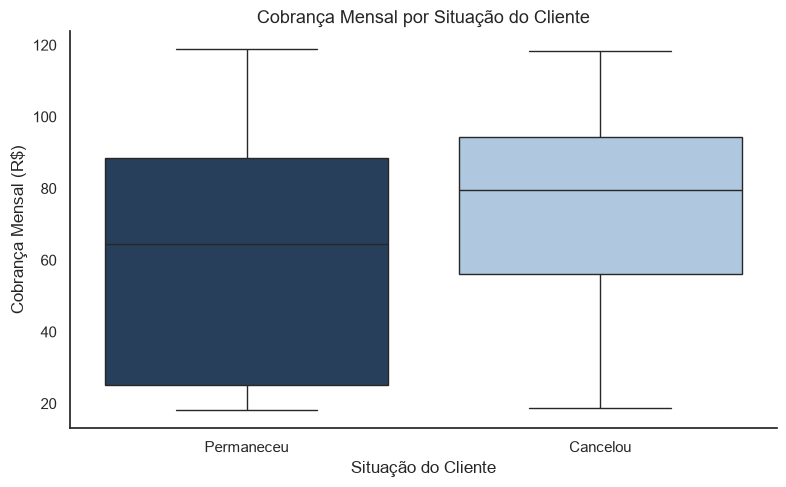

In [444]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_tratado,
    x="cancelamento",
    y="cobranca_mensal",
    hue="cancelamento",
    palette=["#1E3F63", "#A7C7E7"],
    legend=False
)

ax.set_xticklabels(["Permaneceu", "Cancelou"])

plt.title("Cobrança Mensal por Situação do Cliente", fontsize=13)
plt.xlabel("Situação do Cliente")
plt.ylabel("Cobrança Mensal (R$)")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/boxplot_cobranca_mensal.png", dpi=300)

plt.show()

In [445]:
df_tratado.groupby("cancelamento")["cobranca_mensal"].describe()

,count,mean,std,min,25%,50%,75%,max
cancelamento,,,,,,,,
Não,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Sim,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


#### Interpretação

Ao comparar os clientes que permaneceram com aqueles que cancelaram os serviços, observa-se que os clientes que cancelaram apresentam cobrança mensal mais elevada. A média da cobrança mensal entre os clientes que cancelaram foi de aproximadamente R$ 74,44, enquanto entre os clientes que permaneceram foi de R$ 61,27.

A mediana também confirma esse comportamento, indicando que clientes que cancelaram tendem a pagar mensalidades superiores. Esse resultado sugere que planos com mensalidades mais elevadas apresentam maior associação com o cancelamento dos serviços.

# 5.6.4 Distribuição da Cobrança Total

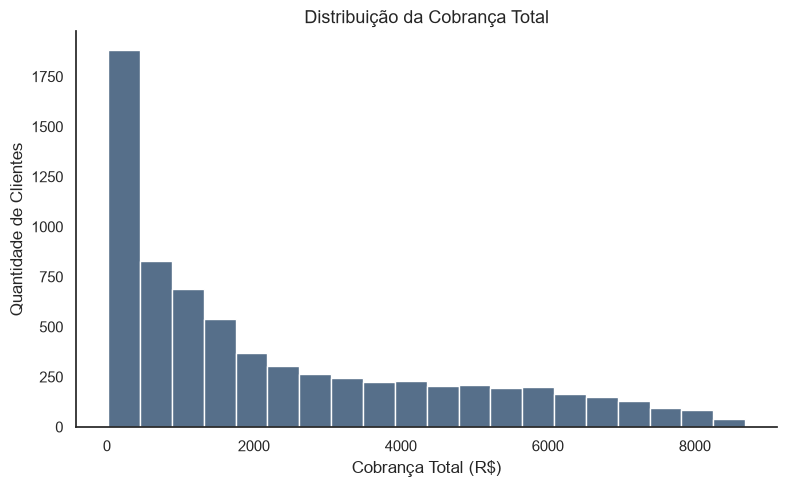

In [446]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_tratado,
    x="cobranca_total",
    bins=20,
    color="#1E3F63"
)

plt.title("Distribuição da Cobrança Total", fontsize=13)
plt.xlabel("Cobrança Total (R$)")
plt.ylabel("Quantidade de Clientes")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/distribuicao_cobranca_total.png", dpi=300)

plt.show()

### Interpretação

A distribuição da cobrança total apresenta forte assimetria à direita, indicando que a maior parte dos clientes acumulou valores relativamente baixos ao longo do relacionamento com a operadora, enquanto uma parcela menor concentrou cobranças totais bastante elevadas.

Observa-se uma elevada concentração de clientes nas faixas iniciais de cobrança total, seguida por uma redução gradual na frequência conforme os valores aumentam. Esse comportamento é esperado, uma vez que a cobrança total está diretamente relacionada ao tempo de permanência do cliente na empresa.

Assim, clientes com menor tempo de permanência tendem a apresentar cobranças totais reduzidas, enquanto clientes mais antigos acumulam valores significativamente maiores ao longo do período em que permanecem utilizando os serviços da operadora.

## 5.6.5 Cobrança Total × Cancelamento

C:\Users\janyne\AppData\Local\Temp\ipykernel_6164\2979685686.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Permaneceu", "Cancelou"])


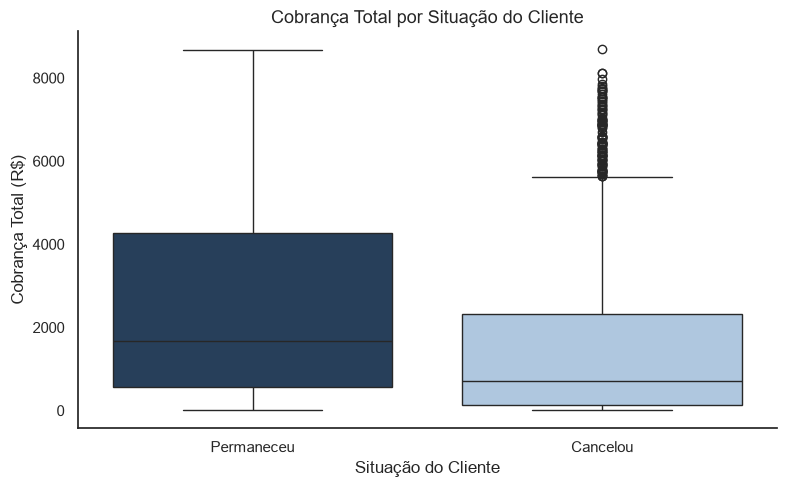

In [447]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_tratado,
    x="cancelamento",
    y="cobranca_total",
    hue="cancelamento",
    palette=["#1E3F63", "#A7C7E7"],
    legend=False
)

ax.set_xticklabels(["Permaneceu", "Cancelou"])

plt.title("Cobrança Total por Situação do Cliente", fontsize=13)
plt.xlabel("Situação do Cliente")
plt.ylabel("Cobrança Total (R$)")

sns.despine()

plt.tight_layout()

plt.savefig("../graficos/boxplot_cobranca_total.png", dpi=300)

plt.show()

In [448]:
df_tratado.groupby("cancelamento")["cobranca_total"].describe()

,count,mean,std,min,25%,50%,75%,max
cancelamento,,,,,,,,
Não,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Sim,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


### Interpretação

O boxplot evidencia que os clientes que permaneceram na operadora apresentaram uma cobrança total significativamente maior do que aqueles que cancelaram os serviços. A mediana da cobrança total dos clientes que permaneceram foi de aproximadamente **R$ 1.683,60**, enquanto entre os clientes que cancelaram foi de aproximadamente **R$ 703,55**.

As estatísticas descritivas confirmam esse comportamento. A média da cobrança total foi de **R$ 2.555,34** para os clientes que permaneceram, contra **R$ 1.531,80** para os clientes que cancelaram.

Observa-se ainda a presença de valores extremos (outliers) entre os clientes que cancelaram, indicando que alguns permaneceram por um longo período antes de encerrar o contrato. Entretanto, esses casos representam uma pequena parcela da base de dados.

Esses resultados reforçam que a cobrança total está diretamente relacionada ao tempo de permanência do cliente na operadora, representando o valor acumulado durante todo o período de relacionamento. Assim, clientes que permanecem por mais tempo naturalmente apresentam cobranças totais mais elevadas.

# 5.6.6 Método de Pagamento

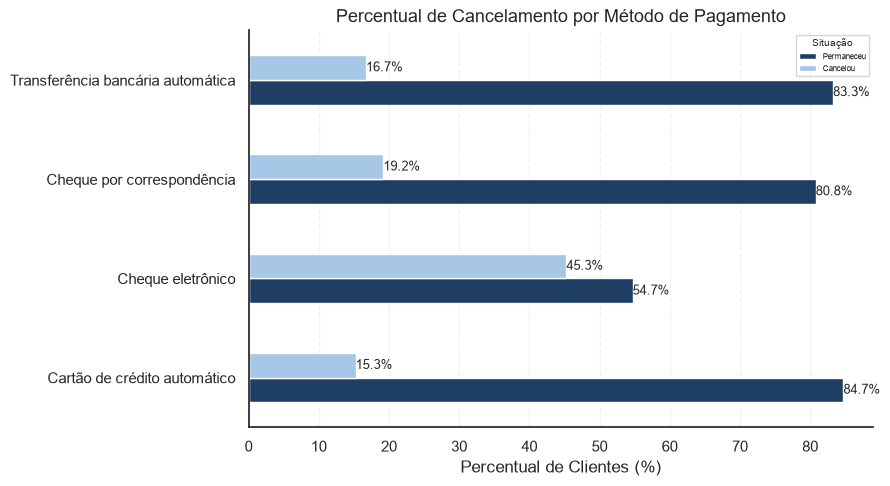

In [449]:
tabela = (
    pd.crosstab(
        df_tratado["metodo_pagamento"],
        df_tratado["cancelamento"],
        normalize="index"
    ) * 100
)

tabela = tabela[["Não", "Sim"]]

ax = tabela.plot(
    kind="barh",
    figsize=(9,5),
    color=["#1E3F63", "#A7C7E7"]
)

plt.title("Percentual de Cancelamento por Método de Pagamento", fontsize=13)
plt.xlabel("Percentual de Clientes (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

ax.grid(axis="x", linestyle="--", alpha=0.3)

sns.despine()

ax.legend(
    title="Situação",
    labels=["Permaneceu", "Cancelou"],
    fontsize=6,
    title_fontsize=7,
    loc="upper right"
)

plt.tight_layout()
plt.savefig("../graficos/cancelamento_por_metodo_pagamento.png", dpi=300)
plt.show()

### Interpretação

O método de pagamento apresentou associação com a taxa de cancelamento dos clientes. Entre as modalidades analisadas, o **cheque eletrônico** foi o método que apresentou a maior proporção de cancelamentos, com aproximadamente **45,3%** dos clientes encerrando os serviços, sendo também o grupo com menor percentual de permanência (54,7%).

Em contrapartida, os clientes que utilizam **cartão de crédito automático** apresentaram a menor taxa de cancelamento (**15,3%**), seguidos pelos que utilizam **transferência bancária automática** (**16,7%**) e **cheque por correspondência** (**19,2%**).

Esses resultados sugerem que clientes que utilizam formas de pagamento automáticas tendem a apresentar maior permanência na operadora, enquanto aqueles que utilizam cheque eletrônico demonstram maior propensão ao cancelamento. No entanto, essa relação representa uma associação observada nos dados e não deve ser interpretada, isoladamente, como uma relação de causa e efeito, podendo estar relacionada a outras características do perfil dos clientes.

# 5.6.7 Fatura Digital

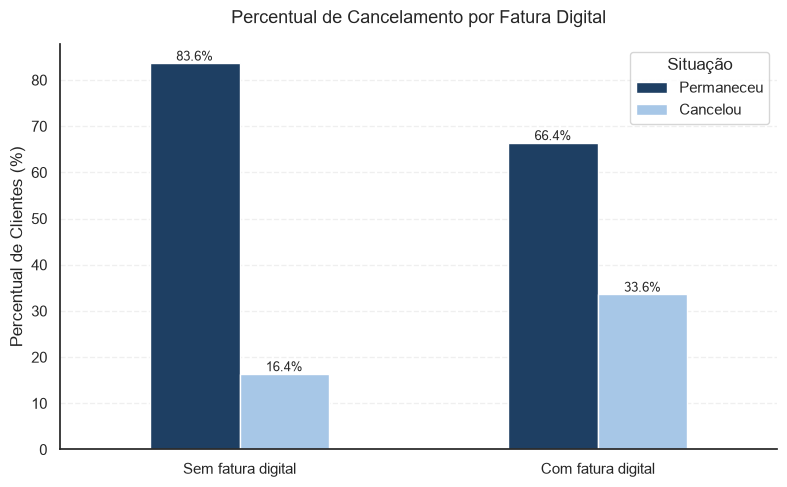

In [450]:
grafico_cancelamento_categoria(
    coluna="fatura_digital",
    titulo="Percentual de Cancelamento por Fatura Digital",
    nome_arquivo="cancelamento_por_fatura_digital"
)

### Interpretação

Observa-se que os clientes que utilizam **fatura digital** apresentam uma taxa de cancelamento significativamente superior à daqueles que não utilizam esse recurso. Entre os clientes com fatura digital, aproximadamente **33,6%** cancelaram os serviços, enquanto entre os clientes que não utilizam fatura digital essa taxa foi de apenas **16,4%**.

Por outro lado, **83,6%** dos clientes sem fatura digital permaneceram na operadora, contra **66,4%** entre os que utilizam esse tipo de faturamento.

Esses resultados indicam uma associação entre o uso da fatura digital e uma maior incidência de cancelamento. Entretanto, essa relação não deve ser interpretada como causal. É possível que clientes que optam pela fatura digital apresentem características específicas, como maior utilização de serviços digitais ou determinados perfis de contratação, que também influenciem sua decisão de cancelar os serviços.